In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_squared_error
from catboost import CatBoostRegressor



In [2]:
df = pd.read_csv('data/mobile_price_prediction.csv')
df

,Brand,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
0,"LG V30+ (Black, 128 )",4.3,4.0,128.0,6.00,48,13.0,4000,24999
1,I Kall K11,3.4,6.0,64.0,4.50,48,12.0,4000,15999
2,Nokia 105 ss,4.3,4.0,4.0,4.50,64,16.0,4000,15000
3,"Samsung Galaxy A50 (White, 64 )",4.4,6.0,64.0,6.40,48,15.0,3800,18999
4,"POCO F1 (Steel Blue, 128 )",4.5,6.0,128.0,6.18,35,15.0,3800,18999
...,...,...,...,...,...,...,...,...,...
831,Karbonn K24 Plus Pro,3.8,6.0,32.0,4.54,48,12.0,2800,1299
832,InFocus POWER 2,4.1,8.0,64.0,4.54,64,NaN,2500,1390
833,"Alcatel 5V (Spectrum Blue, 32 )",4.4,3.0,32.0,6.20,48,1.0,3800,9790
834,JIVI JV 12M,3.7,10.0,32.0,4.50,64,NaN,3500,799


In [3]:
print("Dataset shape:", df.shape)
print("\nData types:")
print(df.dtypes)
print("\nMissing values:")
print(df.isnull().sum())

Dataset shape: (836, 9)

Data types:
Brand                str
Ratings          float64
RAM              float64
ROM              float64
Mobile_Size      float64
Primary_Cam        int64
Selfi_Cam        float64
Battery_Power      int64
Price              int64
dtype: object

Missing values:
Brand              0
Ratings           31
RAM                7
ROM                4
Mobile_Size        2
Primary_Cam        0
Selfi_Cam        269
Battery_Power      0
Price              0
dtype: int64


In [4]:
df.describe()

,Ratings,RAM,ROM,Mobile_Size,Primary_Cam,Selfi_Cam,Battery_Power,Price
count,805.000000,829.000000,832.000000,834.000000,836.000000,567.000000,836.000000,836.00000
mean,4.103106,6.066345,64.373077,5.597282,47.983254,9.784832,3274.688995,18220.34689
std,0.365356,2.530336,53.447825,3.898664,11.170093,6.503838,927.518852,52805.55022
min,2.800000,0.000000,0.000000,2.000000,5.000000,0.000000,1020.000000,479.00000
25%,3.800000,6.000000,32.000000,4.500000,48.000000,5.000000,3000.000000,984.75000
50%,4.100000,6.000000,40.000000,4.770000,48.000000,8.000000,3000.000000,1697.00000
75%,4.400000,6.000000,64.000000,6.300000,48.000000,13.000000,3800.000000,18999.00000
max,4.800000,34.000000,256.000000,44.000000,64.000000,61.000000,6000.000000,573000.00000


In [5]:

num_cols_eda = df.select_dtypes(include=[np.number]).columns
for col in num_cols_eda:
    df[col] = df[col].fillna(df[col].median())
if df["Brand"].isna().any():
    df["Brand"] = df["Brand"].fillna(df["Brand"].mode().iloc[0])


In [6]:
#Removing Outliers
Q1 = df['Price'].quantile(0.25)
Q3 = df['Price'].quantile(0.75)
IQR = Q3 - Q1

lower_bound = Q1 - 1.5 * IQR
upper_bound = Q3 + 1.5 * IQR

df = df[(df['Price'] >= lower_bound) & (df['Price'] <= upper_bound)]

print("\nAfter Outlier Removal Shape:", df.shape)



After Outlier Removal Shape: (774, 9)


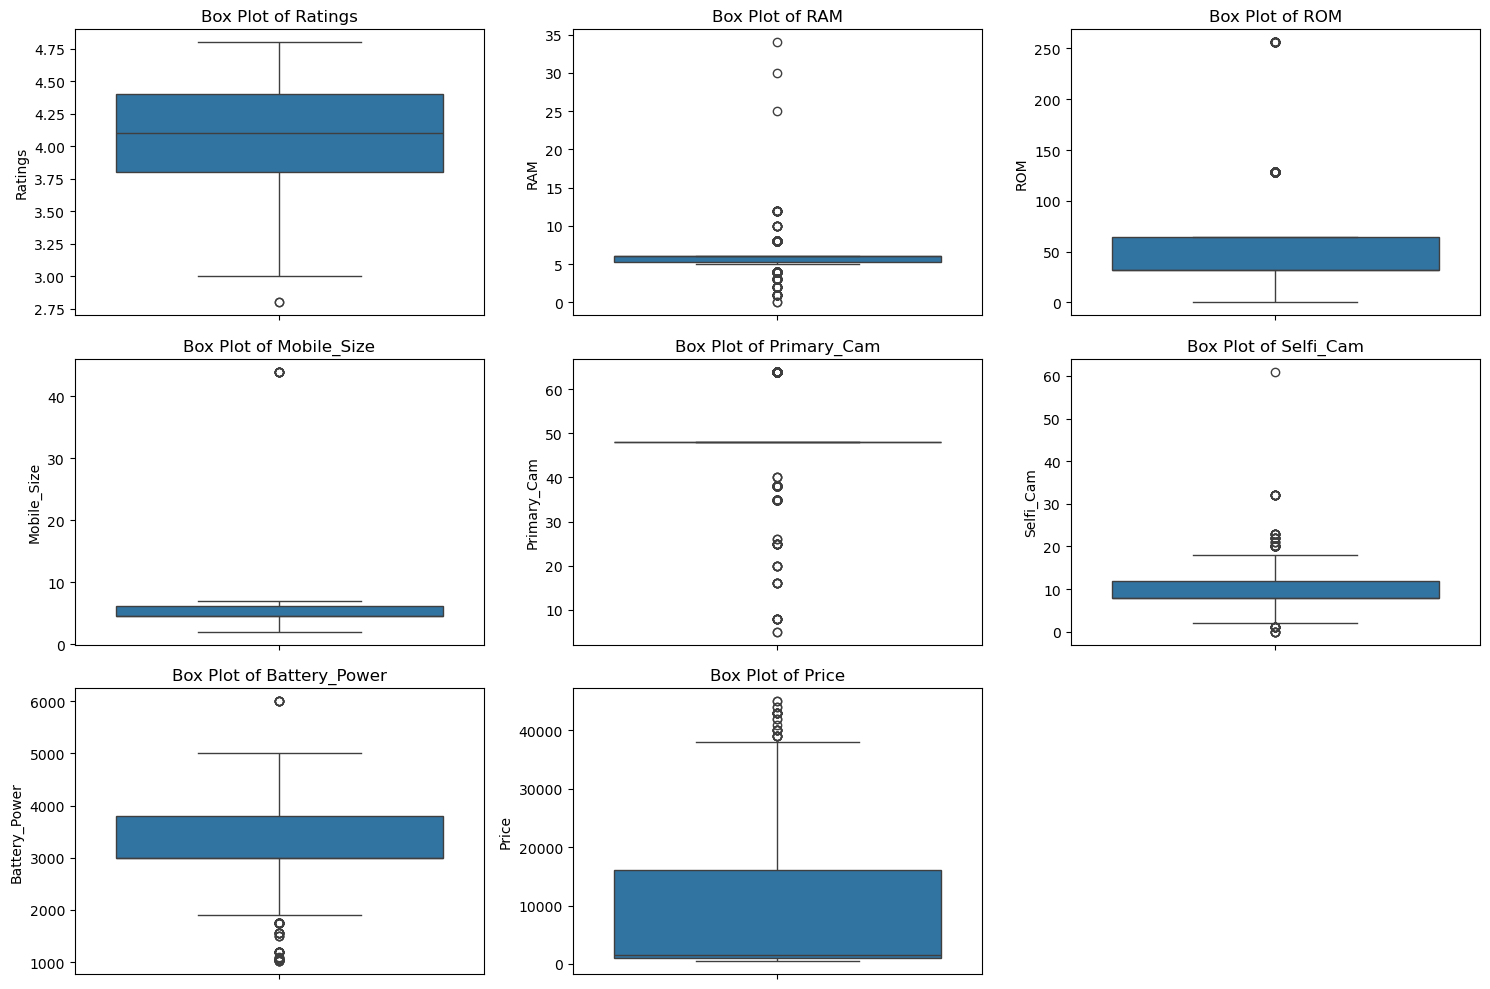

In [7]:
#Boxplots
numerical_features = ['Ratings', 'RAM', 'ROM', 'Mobile_Size', 'Primary_Cam', 'Selfi_Cam', 'Battery_Power','Price']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(numerical_features):
    plt.subplot(3, 3, i+1)
    sns.boxplot(y=df[feature])
    plt.title(f'Box Plot of {feature}')
plt.tight_layout()
plt.show()

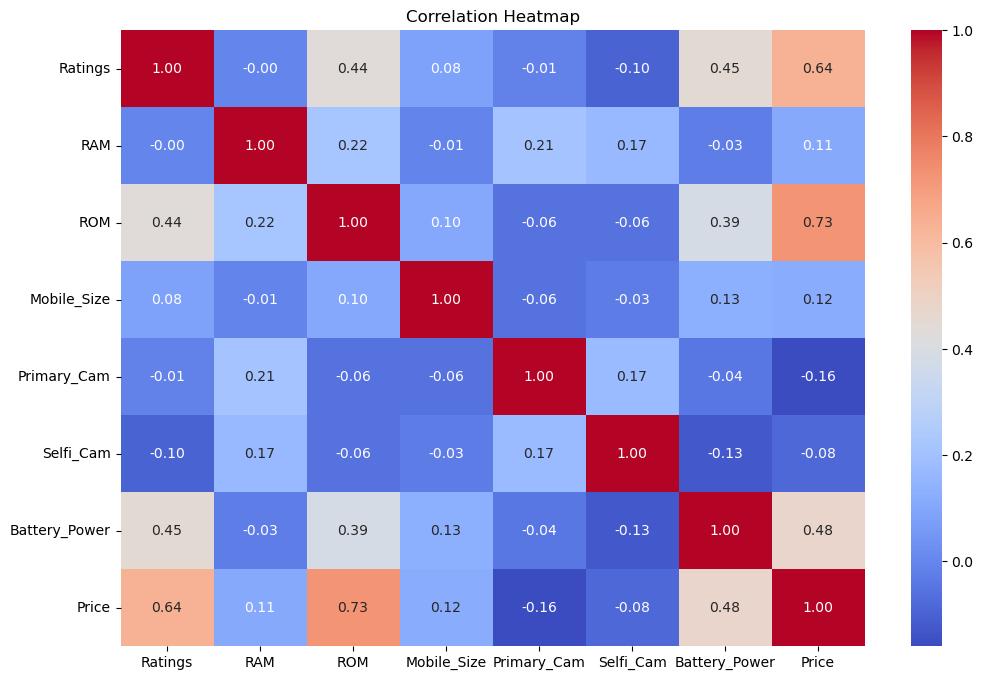

In [8]:
# Correlation heatmap
plt.figure(figsize=(12, 8))
correlation_matrix = df[numerical_features].corr()
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Correlation Heatmap')
plt.show()

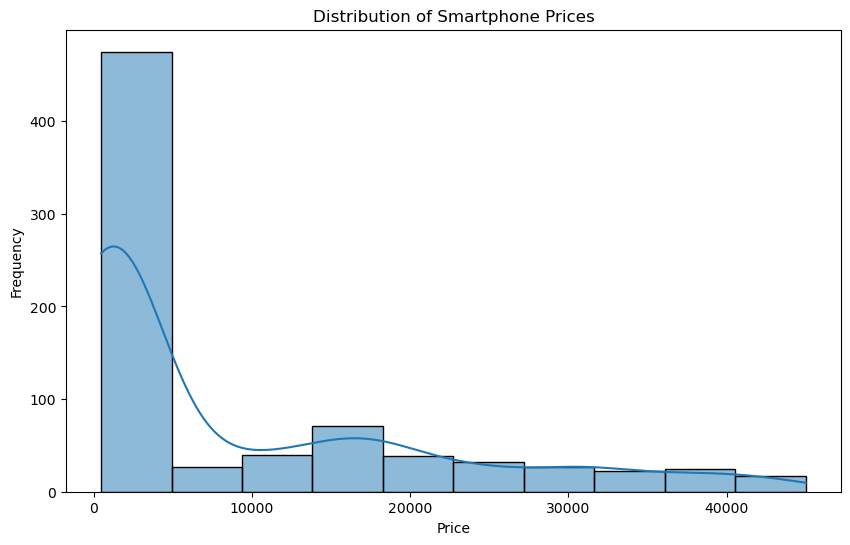

In [9]:
# Distribution of target variable (Price)
plt.figure(figsize=(10, 6))
sns.histplot(df['Price'], bins=10, kde=True)
plt.title('Distribution of Smartphone Prices')
plt.xlabel('Price')
plt.ylabel('Frequency')
plt.show()

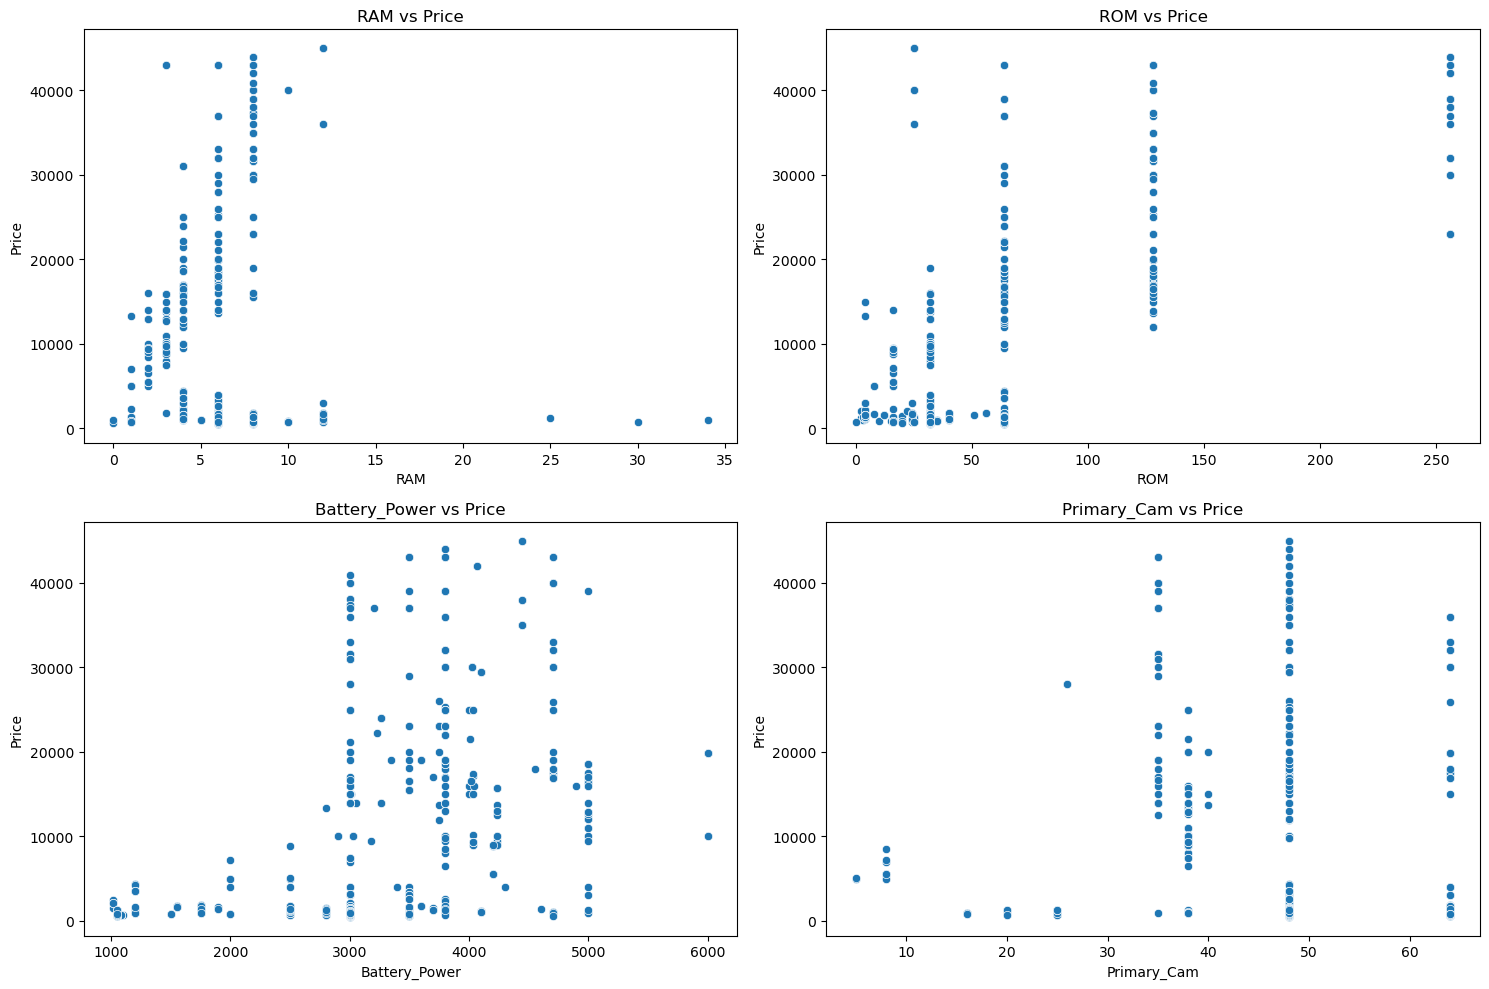

In [10]:
key_features = ['RAM', 'ROM', 'Battery_Power', 'Primary_Cam']
plt.figure(figsize=(15, 10))
for i, feature in enumerate(key_features):
    plt.subplot(2, 2, i+1)
    sns.scatterplot(x=df[feature], y=df['Price'])
    plt.title(f'{feature} vs Price')
    plt.xlabel(feature)
    plt.ylabel('Price')
plt.tight_layout()
plt.show()


Top Brands by Ratings:
 Brand
Infinix     4.600000
OnePlus     4.517647
Apple       4.500000
Google      4.500000
Motorola    4.500000
POCO        4.500000
Realme      4.500000
Redmi       4.472414
Forme       4.450000
Vivo        4.405000
Name: Ratings, dtype: float64


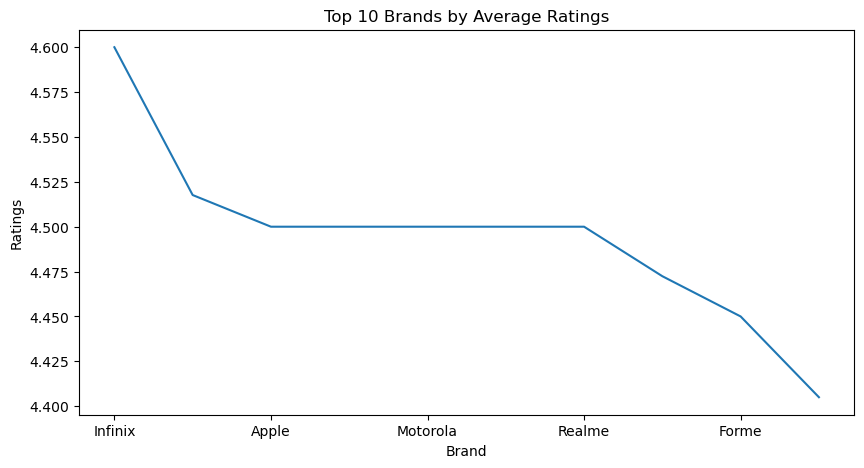

In [11]:
df['Brand'] = df['Brand'].str.split().str[0]

# Average rating per brand
brand_rating = df.groupby('Brand')['Ratings'].mean().sort_values(ascending=False)

print("\nTop Brands by Ratings:\n", brand_rating.head(10))

# Plot
plt.figure(figsize=(10,5))
brand_rating.head(10).plot(kind='line')
plt.title("Top 10 Brands by Average Ratings")
plt.ylabel("Ratings")
plt.show()

In [12]:
# ── Feature Engineering ─────────────────────────────────────────────────────
# spec_score: composite hardware quality metric (no price info -> no leakage)
df["spec_score"] = (
    np.log1p(df["RAM"])
    + np.log1p(df["ROM"])
    + np.log1p(df["Battery_Power"])
    + np.log1p(df["Primary_Cam"])
    + np.log1p(df["Selfi_Cam"])
)

# RAM-to-ROM ratio: storage balance indicator
df["ram_rom_ratio"] = df["RAM"] / (df["ROM"] + 1)

# Camera total
df["total_cam"] = df["Primary_Cam"] + df["Selfi_Cam"]

print("Feature engineering done.")
print("New columns:", ["spec_score", "ram_rom_ratio", "total_cam"])
df[["spec_score", "ram_rom_ratio", "total_cam"]].describe()

Feature engineering done.
New columns: ['spec_score', 'ram_rom_ratio', 'total_cam']


,spec_score,ram_rom_ratio,total_cam
count,774.000000,774.000000,774.000000
mean,19.787688,0.199982,57.742894
std,1.319219,1.087481,13.184227
min,14.241178,0.000000,7.000000
25%,19.132698,0.062016,53.000000
50%,19.820730,0.119430,56.000000
75%,20.619080,0.181818,68.000000
max,22.719299,30.000000,109.000000


In [13]:
# ── Modelling Setup: Brand-Relative Pricing ───────────────────────────────
# Strategy: Price = brand_avg_price + relative_price
#   - Brand baseline captures the brand tier (Samsung vs Nokia vs Apple etc.)
#   - Model learns spec-based variation WITHIN each brand tier
#   - Ensures: higher specs -> higher price within the same brand

TARGET = "Price"

FEATURE_COLS = [
    "Brand", "Ratings", "RAM", "ROM", "Mobile_Size",
    "Primary_Cam", "Selfi_Cam", "Battery_Power",
    "spec_score", "ram_rom_ratio", "total_cam",
    "brand_avg_price", "brand_min_price", "brand_max_price",
]
CAT_FEATURES = ["Brand"]

def impute_train_test(X_train: pd.DataFrame, X_test: pd.DataFrame):
    """Impute missing values; train medians applied to test (no leakage)."""
    X_train = X_train.copy()
    X_test = X_test.copy()
    num_cols = [c for c in X_train.columns if c not in CAT_FEATURES]
    for c in num_cols:
        med = X_train[c].median()
        X_train[c] = X_train[c].fillna(med)
        X_test[c] = X_test[c].fillna(med)
    mode = X_train["Brand"].mode()
    brand_fill = mode.iloc[0] if len(mode) else "unknown"
    X_train["Brand"] = X_train["Brand"].fillna(brand_fill).astype(str)
    X_test["Brand"] = X_test["Brand"].fillna(brand_fill).astype(str)
    return X_train, X_test


# ── SPLIT FIRST, then compute brand stats from TRAIN only (no data leakage)
X_all = df.drop(columns=[TARGET]).copy()
y_all = df[TARGET].copy()

X_pre_train, X_pre_test, y_train_raw, y_test_raw = train_test_split(
    X_all, y_all, test_size=0.2, random_state=42
)

# Brand statistics computed ONLY on training data
train_with_price = X_pre_train.copy()
train_with_price["Price"] = y_train_raw

brand_stats = train_with_price.groupby("Brand")["Price"].agg(
    brand_avg_price="mean",
    brand_min_price="min",
    brand_max_price="max",
).reset_index()

print("Brand-level price stats (from TRAIN split only):")
print(brand_stats.sort_values("brand_avg_price", ascending=False).head(15).to_string(index=False))

# Global fallback for unseen brands in test
global_avg = y_train_raw.mean()
global_min = y_train_raw.min()
global_max = y_train_raw.max()

# Merge brand stats into train & test
X_pre_train = X_pre_train.merge(brand_stats, on="Brand", how="left")
X_pre_test  = X_pre_test.merge(brand_stats, on="Brand", how="left")

# Fill unseen brands with global stats
for col, fallback in [("brand_avg_price", global_avg),
                       ("brand_min_price", global_min),
                       ("brand_max_price", global_max)]:
    X_pre_train[col] = X_pre_train[col].fillna(fallback)
    X_pre_test[col]  = X_pre_test[col].fillna(fallback)

# ── Relative price target: Price - brand_avg_price
y_train = y_train_raw - X_pre_train["brand_avg_price"].values
y_test_relative = y_test_raw - X_pre_test["brand_avg_price"].values

# Keep brand_avg for inverse transform at prediction time
test_brand_avg = X_pre_test["brand_avg_price"].values.copy()
train_brand_avg = X_pre_train["brand_avg_price"].values.copy()

# Select only model features
X_train = X_pre_train[FEATURE_COLS].copy()
X_test  = X_pre_test[FEATURE_COLS].copy()

X_train, X_test = impute_train_test(X_train, X_test)

print(f"\nTrain shape: {X_train.shape}, Test shape: {X_test.shape}")
print(f"Relative price (train) — mean: {y_train.mean():.1f}, std: {y_train.std():.1f}")

Brand-level price stats (from TRAIN split only):
   Brand  brand_avg_price  brand_min_price  brand_max_price
   Nexus     42998.000000            42998            42998
 OnePlus     40181.846154            32999            43999
    iQOO     38275.714286            34990            44990
   Apple     36332.333333            28999            38999
   Black     31999.000000            31999            31999
  Google     30999.000000            30999            30999
Blacerry     24999.000000            24999            24999
  Realme     22033.428571             6499            35999
    POCO     21186.500000            17499            22999
   Redmi     20110.909091             9998            29999
 Samsung     19438.763158             1100            42999
    Vivo     19374.656250             8995            36990
   Honor     19062.636364            13699            25999
    OPPO     18922.176471             8490            38990
      LG     17684.714286            13999         

In [14]:
# ── Train CatBoost on relative_price ──────────────────────────────────────
X_tr, X_val, y_tr, y_val = train_test_split(
    X_train, y_train, test_size=0.15, random_state=42
)

cat_model = CatBoostRegressor(
    iterations=2000,
    learning_rate=0.05,
    depth=6,
    loss_function="RMSE",
    random_seed=42,
    verbose=100,
    early_stopping_rounds=80,
    allow_writing_files=False,
)
cat_model.fit(
    X_tr,
    y_tr,
    cat_features=CAT_FEATURES,
    eval_set=(X_val, y_val),
)

0:	learn: 4588.1265875	test: 5888.8861132	best: 5888.8861132 (0)	total: 158ms	remaining: 5m 15s
100:	learn: 1675.0052642	test: 2839.9701316	best: 2839.9701316 (100)	total: 4s	remaining: 1m 15s
200:	learn: 1136.0750094	test: 2535.3333593	best: 2535.3333593 (200)	total: 7.47s	remaining: 1m 6s
300:	learn: 865.8516100	test: 2450.3264236	best: 2446.9235595 (274)	total: 11.1s	remaining: 1m 2s
400:	learn: 662.8218964	test: 2436.1052520	best: 2428.5310295 (383)	total: 14.2s	remaining: 56.6s
Stopped by overfitting detector  (80 iterations wait)

bestTest = 2428.53103
bestIteration = 383

Shrink model to first 384 iterations.


CatBoostRegressor(allow_writing_files=False, depth=6, early_stopping_rounds=80, iterations=2000, learning_rate=0.05, loss_function='RMSE', random_seed=42, verbose=100)

In [15]:
# ── Save model + brand stats for backend ─────────────────────────────────
artifact = {
    "model": cat_model,
    "cat_features": CAT_FEATURES,
    "feature_cols": FEATURE_COLS,
    "brand_stats": brand_stats,            # DataFrame with brand_avg/min/max
    "global_avg": global_avg,
    "global_min": global_min,
    "global_max": global_max,
}
joblib.dump(artifact, "backend/mobile_price_pipeline.pkl")
print("Saved mobile_price_pipeline.pkl (CatBoost + brand-relative pricing)")

Saved mobile_price_pipeline.pkl (CatBoost + brand-relative pricing)


In [25]:
# ── Evaluation: predictions in ORIGINAL price scale ──────────────────────
# Model predicts relative_price; final_price = predicted_relative + brand_avg

# Test set
y_pred_relative = cat_model.predict(X_test)
y_pred = y_pred_relative + test_brand_avg          # back to original scale
y_test = y_test_raw.values                         # original prices

rmse = float(np.sqrt(mean_squared_error(y_test, y_pred)))
r2   = float(r2_score(y_test, y_pred))
mae  = float(np.mean(np.abs(y_test - y_pred)))


print(f"RMSE: {rmse:,.2f}")
print(f"MAE:  {mae:,.2f}")
print(f"R²:   {r2:.4f}")


RMSE: 2,165.75
MAE:  1,132.28
R²:   0.9712


In [24]:
# ── Train metrics (sanity check) ──────────────────────────────────────────
y_pred_train_rel = cat_model.predict(X_train)
y_pred_train = y_pred_train_rel + train_brand_avg
print(
    " RMSE:", np.sqrt(mean_squared_error(y_train_raw.values, y_pred_train)),
    "\n R²:", r2_score(y_train_raw.values, y_pred_train),
)



 RMSE: 1194.6164162107455 
 R²: 0.9896161579154219


        Feature  Importance
brand_avg_price   13.906642
brand_max_price   13.711782
     spec_score   13.294754
    Mobile_Size   12.712637
            RAM    8.710351
  Battery_Power    7.848462
brand_min_price    6.819936
      Selfi_Cam    5.726220
        Ratings    4.060631
      total_cam    3.308632
            ROM    3.302556
    Primary_Cam    2.696854
  ram_rom_ratio    2.425175
          Brand    1.475368

── Importance Breakdown ──
  Brand (categorical):  1.5%
  Brand stats:          34.4%
  Spec features:        47.3%


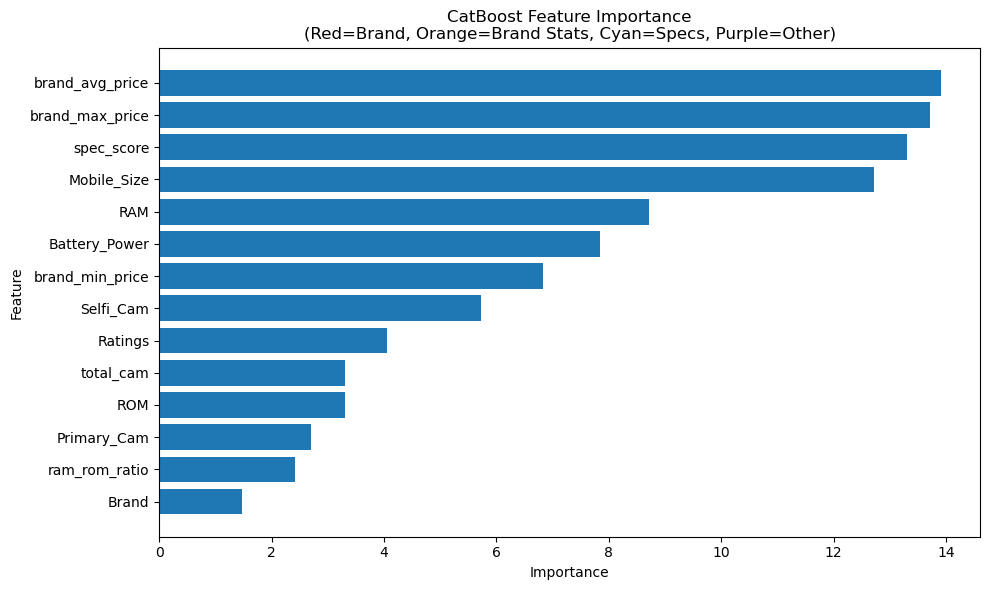

In [20]:
# ── Explainability: Feature importance ────────────────────────────────────
feat_imp = pd.DataFrame({
    "Feature": cat_model.feature_names_,
    "Importance": cat_model.feature_importances_,
}).sort_values("Importance", ascending=False)

print(feat_imp.to_string(index=False))

# Highlight brand vs spec contributions
brand_imp = feat_imp[feat_imp["Feature"] == "Brand"]["Importance"].sum()
spec_features = ["RAM", "ROM", "Battery_Power", "Primary_Cam", "Selfi_Cam",
                  "spec_score", "ram_rom_ratio", "total_cam"]
spec_imp = feat_imp[feat_imp["Feature"].isin(spec_features)]["Importance"].sum()
brand_stat_imp = feat_imp[feat_imp["Feature"].str.startswith("brand_")]["Importance"].sum()
total = feat_imp["Importance"].sum()

print(f"\n── Importance Breakdown ──")
print(f"  Brand (categorical):  {100*brand_imp/total:.1f}%")
print(f"  Brand stats:          {100*brand_stat_imp/total:.1f}%")
print(f"  Spec features:        {100*spec_imp/total:.1f}%")

plt.figure(figsize=(10, 6))

plt.barh(feat_imp["Feature"], feat_imp["Importance"])
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("CatBoost Feature Importance\n(Red=Brand, Orange=Brand Stats, Cyan=Specs, Purple=Other)")
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()